# Imports 

In [1]:
print('test')

test


In [2]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from burgers_rom.config import RunConfig, DataConfig, PODConfig, DerivConfig, SINDyConfig, RolloutConfig
from burgers_rom.run_pipeline import run


# 0. Config

In [ ]:
cfg = RunConfig(
    name="debug_single",
    seed=0,
    data=DataConfig(
        equation="burgers",
        structure="grid",
        resolution="low",
        split="train",
        n_trajectories=1,
        trajectory_ids=None,
        lookback=200,
        download_if_missing=False,
        time_stride=1,
        time_limit=None,
    ),
    pod=PODConfig(
        rank=None,
        energy_fraction=0.7,
        center=True,
    ),
    deriv=DerivConfig(),
    sindy=SINDyConfig(
        poly_order=2,
        include_bias=False,
        optimizer="stlsq",
        optimizer_kwargs=None,
        constrain_energy=False,
    ),  
    rollout=RolloutConfig(
        horizon_steps=50,
    ),
    # outputs_dir="outputs",
)

result = run(cfg, write_artifacts=True)
result.run_id, result.rundir


TypeError: STLSQ.__init__() got an unexpected keyword argument 'sparsity'

# 1. POD singular values

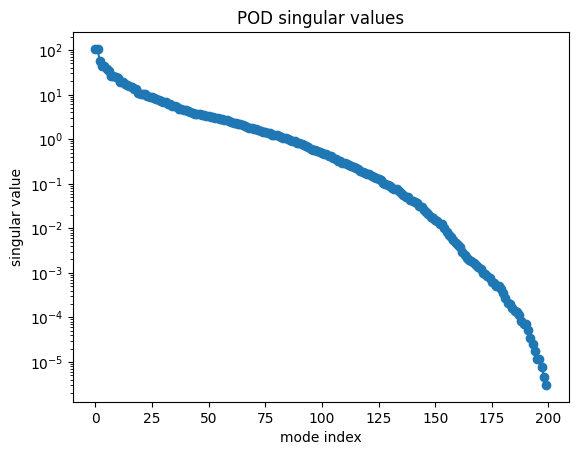

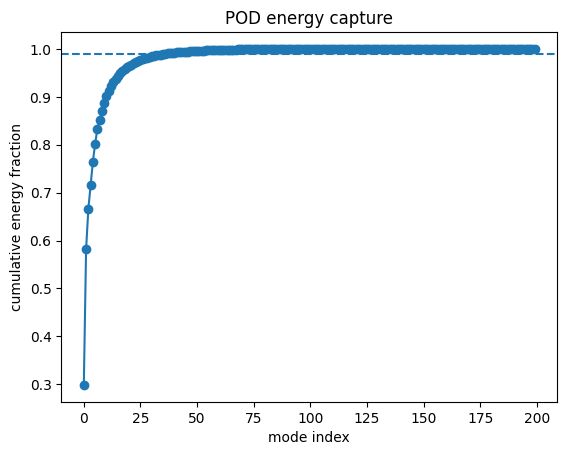

(4, 0.7159674797156574)

In [ ]:
s = result.pod.s
plt.figure()
plt.semilogy(s, marker="o")
plt.xlabel("mode index")
plt.ylabel("singular value")
plt.title("POD singular values")
plt.show()

energy = s**2
cum = np.cumsum(energy) / np.sum(energy)
plt.figure()
plt.plot(cum, marker="o")
plt.axhline(0.99, linestyle="--")
plt.xlabel("mode index")
plt.ylabel("cumulative energy fraction")
plt.title("POD energy capture")
plt.show()

result.pod.r, result.pod.energy_fraction


# 2. SINDy sparity diagnostics

Xi shape: (4, 14)
nonzeros: 0
density: 0.0


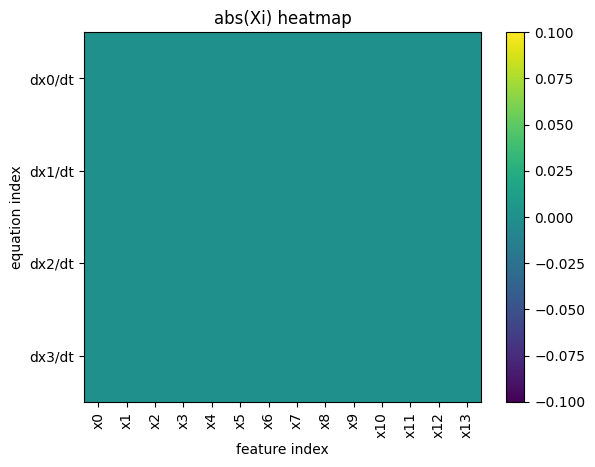

In [ ]:
Xi = result.sindy.coefficient_matrix
n_targets, n_features = Xi.shape
nnz = np.count_nonzero(Xi)
density = nnz / Xi.size

print("Xi shape:", Xi.shape)
print("nonzeros:", nnz)
print("density:", density)

plt.figure()
plt.imshow(np.abs(Xi), aspect="auto")
# more descriptive plot labels
plt.xticks(ticks=np.arange(n_features), labels=[f"x{i}" for i in range(n_features)], rotation=90)
plt.yticks(ticks=np.arange(n_targets), labels=[f"dx{i}/dt" for i in range(n_targets)])
# let's use sympy to write the ticks in terms of the actual sindy library functions, e.g. x0, x1, x0^2, x0*x1, etc.
import sympy as sp
# x = sp.symbols("x0:%d" % n_features)
# feature_labels = []
# for i in range(n_features):
#     print("i:", i)
#     if i < n_targets:
#         feature_labels.append(f"x{i}")
#     else:
#         # we need to figure out which polynomial term this corresponds to
#         # we can use the SINDy library's function to get the feature names
#         from pysindy.feature_library import PolynomialLibrary
#         poly_lib = PolynomialLibrary(degree=cfg.sindy.poly_order, include_bias=cfg.sindy.include_bias)
#         feature_names = poly_lib.get_feature_names(x)
#         feature_labels.append(feature_names[i])
# plt.xticks(ticks=np.arange(n_features), labels=feature_labels, rotation=90)
plt.xlabel("feature index")
plt.ylabel("equation index")
plt.title("abs(Xi) heatmap")
plt.colorbar()
plt.show()


# 4. Load plots

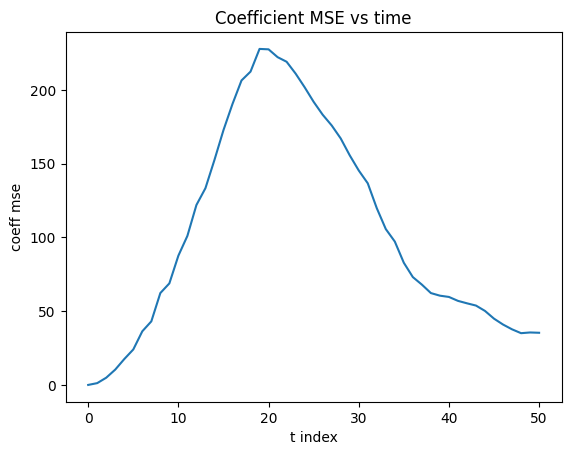

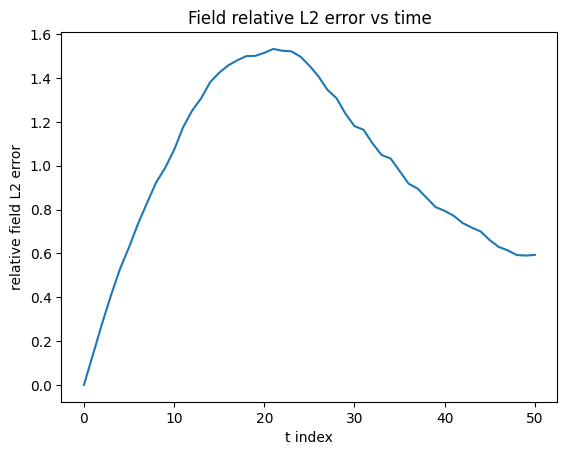

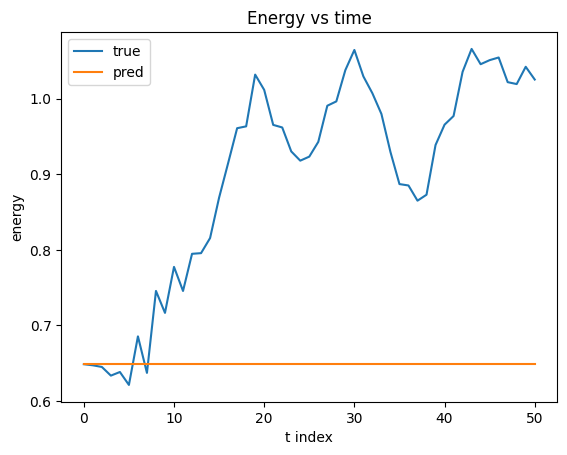

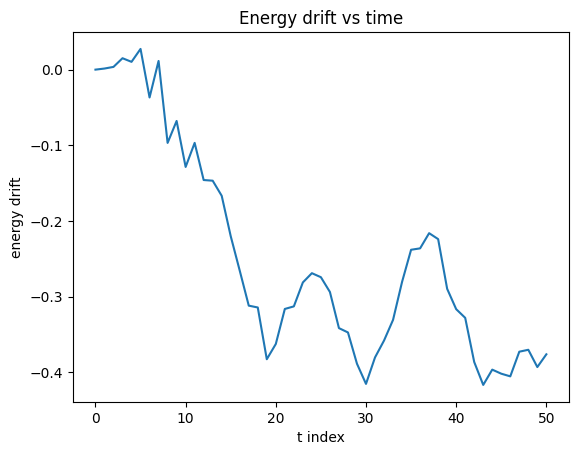

In [ ]:
rundir = Path(result.rundir)
with (rundir / "metrics" / "curves.json").open("r", encoding="utf-8") as f:
    curves = json.load(f)

coeff_mse = np.array(curves["coeff_mse"])
field_rel = np.array(curves["field_rel_l2"])
energy_true = np.array(curves["energy_true"])
energy_pred = np.array(curves["energy_pred"])

plt.figure()
plt.plot(coeff_mse)
plt.xlabel("t index")
plt.ylabel("coeff mse")
plt.title("Coefficient MSE vs time")
plt.show()

plt.figure()
plt.plot(field_rel)
plt.xlabel("t index")
plt.ylabel("relative field L2 error")
plt.title("Field relative L2 error vs time")
plt.show()

plt.figure()
plt.plot(energy_true, label="true")
plt.plot(energy_pred, label="pred")
plt.xlabel("t index")
plt.ylabel("energy")
plt.title("Energy vs time")
plt.legend()
plt.show()

plt.figure()
plt.plot(energy_pred - energy_true)
plt.xlabel("t index")
plt.ylabel("energy drift")
plt.title("Energy drift vs time")
plt.show()


# 5. Visualize true versus predicted components

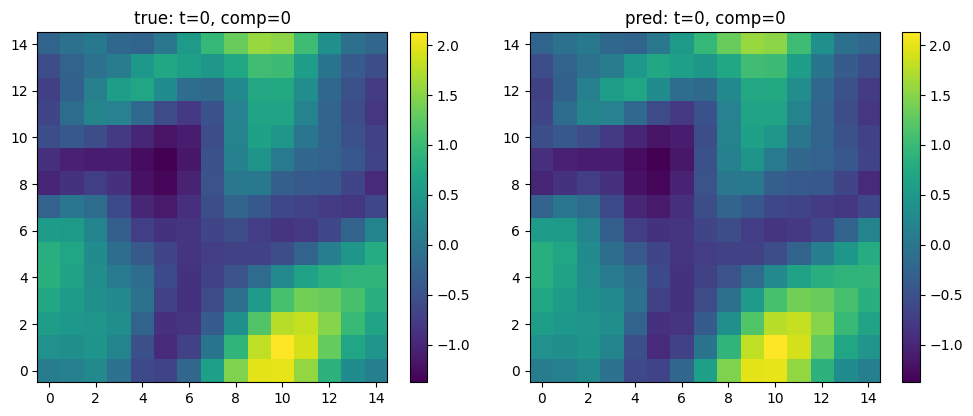

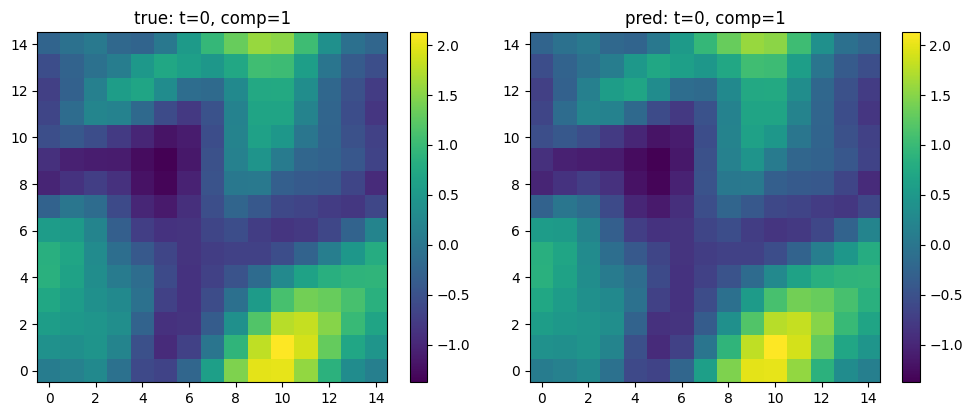

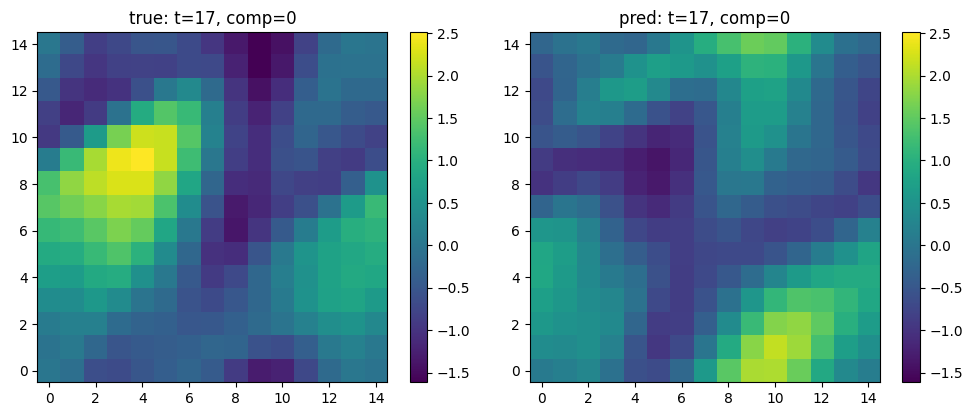

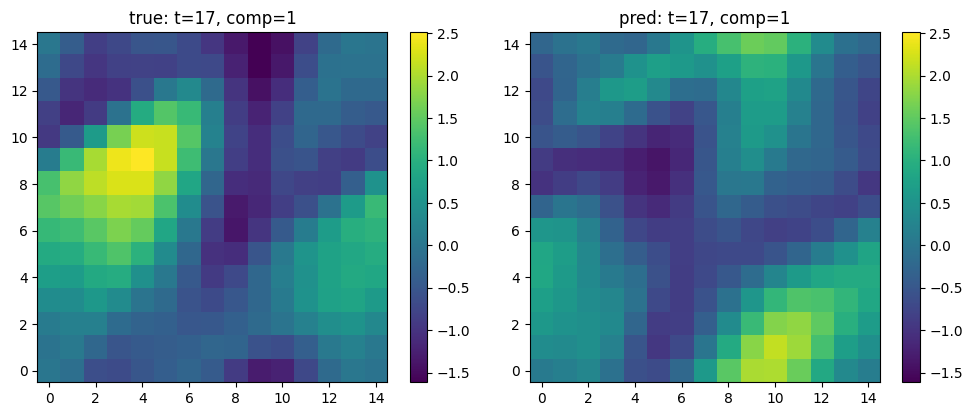

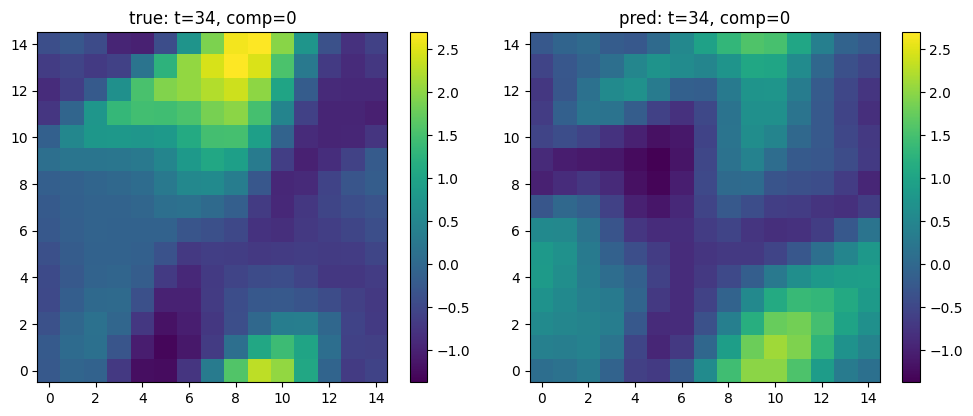

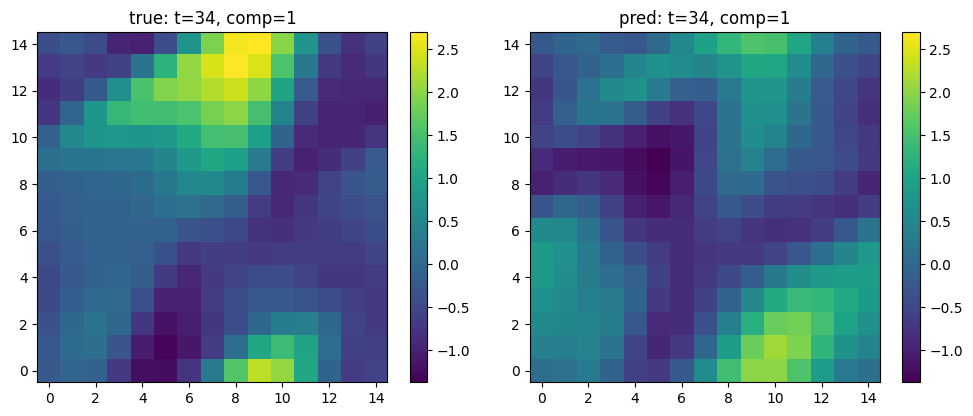

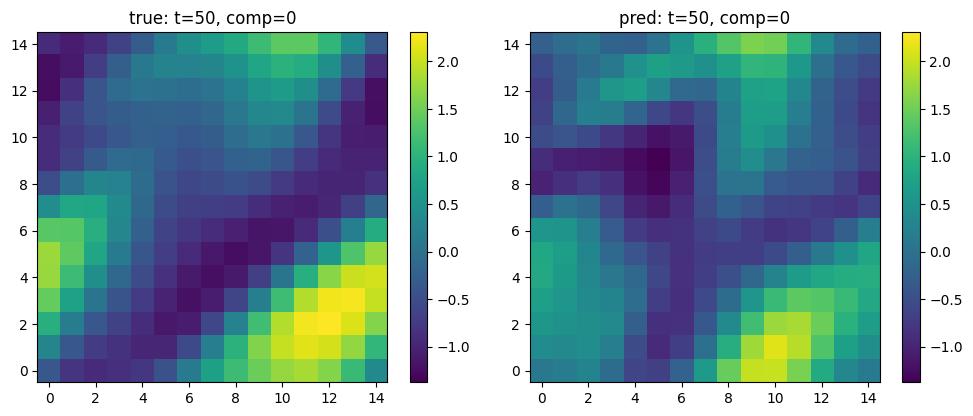

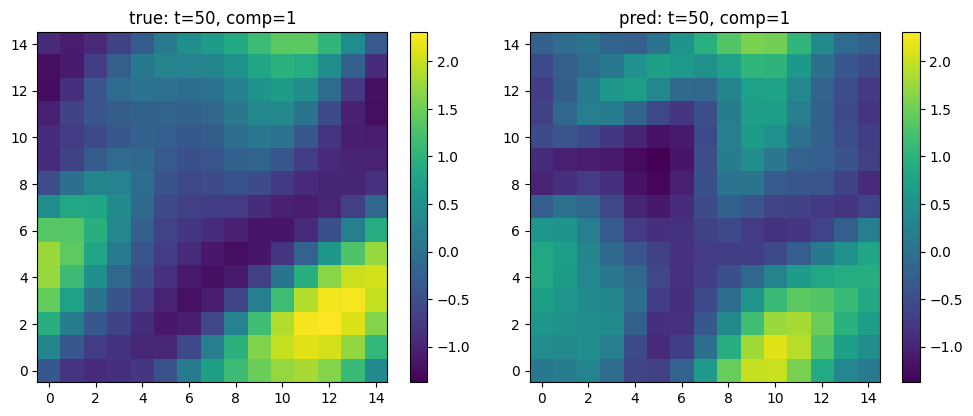

In [ ]:
fields_true = result.rollout.fields_true
fields_pred = result.rollout.fields_pred

# Burgers has 2 components. Plot component 0 and 1 separately.
times = [0, len(fields_true)//3, 2*len(fields_true)//3, len(fields_true)-1]

def show_pair(t_idx: int, comp: int) -> None:
    ft = fields_true[t_idx, comp]
    fp = fields_pred[t_idx, comp]
    vmin = min(ft.min(), fp.min())
    vmax = max(ft.max(), fp.max())

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(ft, origin="lower", vmin=vmin, vmax=vmax, aspect="equal")
    plt.title(f"true: t={t_idx}, comp={comp}")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(fp, origin="lower", vmin=vmin, vmax=vmax, aspect="equal")
    plt.title(f"pred: t={t_idx}, comp={comp}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

for t_idx in times:
    show_pair(t_idx, comp=0)
    show_pair(t_idx, comp=1)


# 6. Save movie

In [ ]:
import imageio.v2 as imageio

out_dir = Path(result.rundir) / "movies"
out_dir.mkdir(parents=True, exist_ok=True)

gif_path = out_dir / "burgers_true_vs_pred_comp0.gif"

frames = []
for t_idx in range(fields_true.shape[0]):
    ft = fields_true[t_idx, 0]
    fp = fields_pred[t_idx, 0]
    vmin = min(ft.min(), fp.min())
    vmax = max(ft.max(), fp.max())

    fig, ax = plt.subplots(1, 2, figsize=(8, 3), dpi=120)
    ax[0].imshow(ft, origin="lower", vmin=vmin, vmax=vmax)
    ax[0].set_title("true comp0")
    ax[0].axis("off")

    ax[1].imshow(fp, origin="lower", vmin=vmin, vmax=vmax)
    ax[1].set_title("pred comp0")
    ax[1].axis("off")

    fig.tight_layout()
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)[:, :, :3]
    frames.append(frame)
    plt.close(fig)

imageio.mimsave(gif_path, frames, duration=0.06, loop=0)
gif_path


PosixPath('/scratch/st-cthrampo-1/tate/enph479/erd-capstone/burgers_rom/outputs/burgers/bf6395755b4c/movies/burgers_true_vs_pred_comp0.gif')